<a href="https://colab.research.google.com/github/nicholas-schwier-class/Stats-Sum-26/blob/main/Class_16_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.decomposition import PCA

In [36]:
digits = load_digits()

X = digits.data
y = digits.target

print(X.shape)
print(y.shape)

(1797, 64)
(1797,)


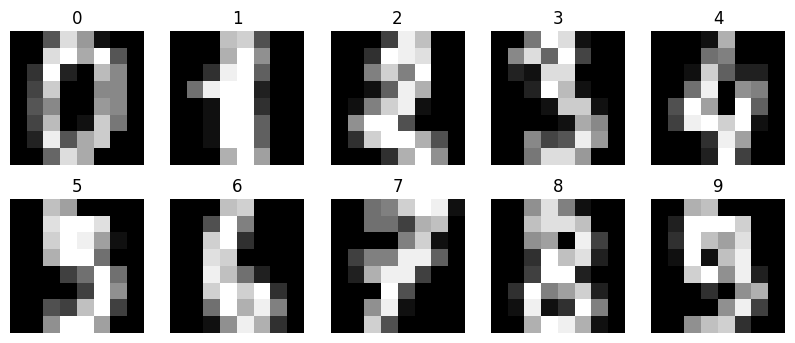

In [37]:
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(digits.target[i])
    plt.axis("off")

plt.show()

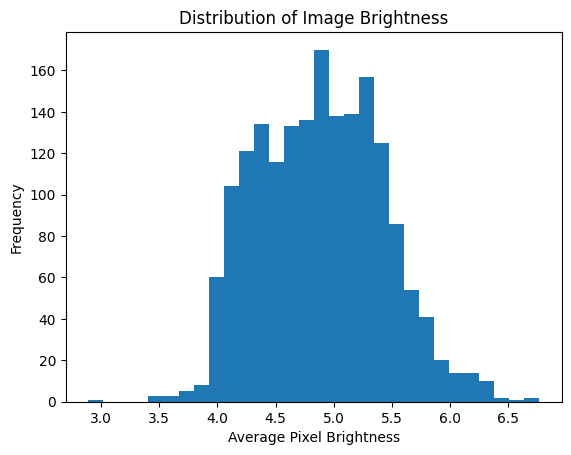

In [38]:
mean_pixels = X.mean(axis=1)

plt.hist(mean_pixels, bins=30)

plt.xlabel("Average Pixel Brightness")
plt.ylabel("Frequency")
plt.title("Distribution of Image Brightness")

plt.show()

Questions

Are most images dark?

Are most images bright?

Why?

Standard Deviation of Images

Images with more detail have greater variability.

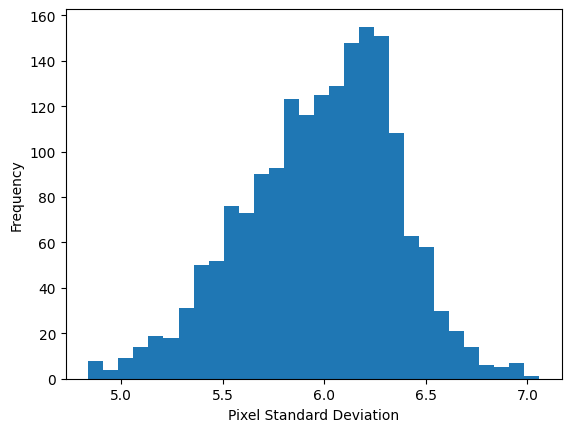

In [39]:
std_pixels = X.std(axis=1)

plt.hist(std_pixels, bins=30)

plt.xlabel("Pixel Standard Deviation")
plt.ylabel("Frequency")

plt.show()

Preparing Training and Testing Data

Typical split

70% training
30% testing

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

Why standardize?

Many machine learning algorithms perform better when variables have similar scales

In [41]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Logistic Regression Classifier

The model learns relationships between pixel intensities and digit labels.

In [42]:
model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

Making Predictions

In [43]:
predictions = model.predict(X_test)

print(predictions[:20])

[6 9 3 7 2 2 5 2 5 2 1 9 4 0 4 2 3 7 8 8]


Accuracy

In [44]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9703703703703703


Confusion matrix

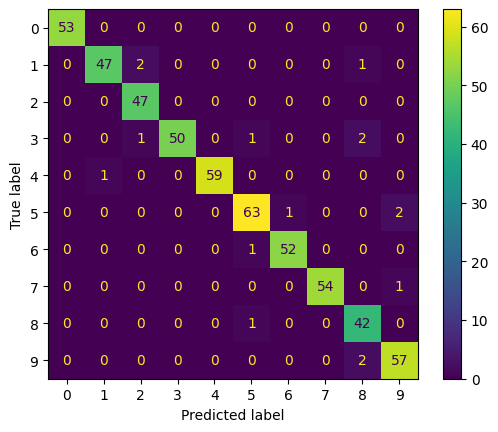

In [45]:
cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.show()

Interpretation

Rows

Actual labels

Columns

Predicted labels

Diagonal values

Correct classifications

Classification Report

Important statistics

Precision
Recall
F1 Score
Support

In [46]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       0.98      0.94      0.96        50
           2       0.94      1.00      0.97        47
           3       1.00      0.93      0.96        54
           4       1.00      0.98      0.99        60
           5       0.95      0.95      0.95        66
           6       0.98      0.98      0.98        53
           7       1.00      0.98      0.99        55
           8       0.89      0.98      0.93        43
           9       0.95      0.97      0.96        59

    accuracy                           0.97       540
   macro avg       0.97      0.97      0.97       540
weighted avg       0.97      0.97      0.97       540



Principal Component Analysis (PCA)

Images contain many variables.

PCA reduces dimensions while preserving information.

In [50]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

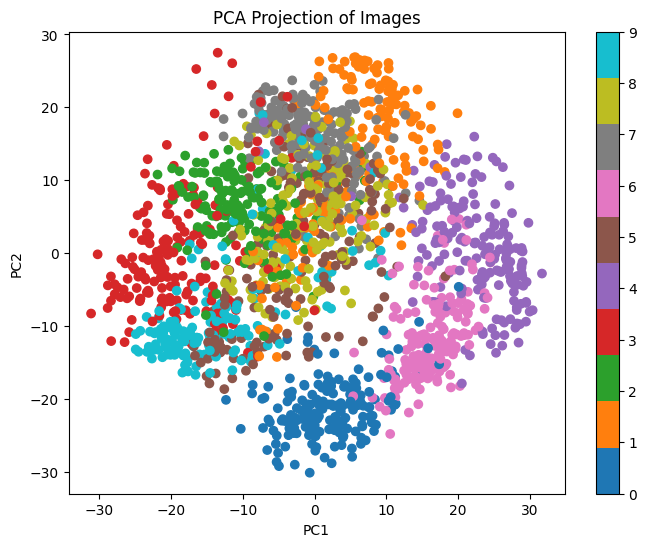

In [51]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap='tab10'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of Images")

plt.colorbar(scatter)

plt.show()

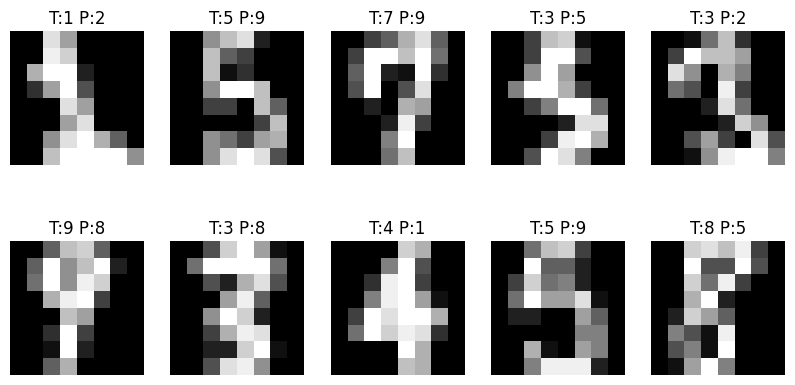

In [52]:
incorrect = np.where(predictions != y_test)[0]

plt.figure(figsize=(10,5))

for i, idx in enumerate(incorrect[:10]):
    plt.subplot(2,5,i+1)

    plt.imshow(
        scaler.inverse_transform(X_test[idx].reshape(1,-1)).reshape(8,8),
        cmap='gray'
    )

    plt.title(f"T:{y_test[idx]} P:{predictions[idx]}")

    plt.axis("off")

plt.show()